# Import Library

In [2]:
import pandas as pd
import json
import os

# Load Dataset 2020

In [3]:
df_2020 = pd.read_csv("../datasets/2020/reviews.csv")

df_2020.head()

,uid,profile,anime_uid,text,score,scores,link
0,255938,DesolatePsyche,34096,\n \n \n \n ...,8,"{'Overall': '8', 'Story': '8', 'Animation': '8...",https://myanimelist.net/reviews.php?id=255938
1,259117,baekbeans,34599,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",https://myanimelist.net/reviews.php?id=259117
2,253664,skrn,28891,\n \n \n \n ...,7,"{'Overall': '7', 'Story': '7', 'Animation': '9...",https://myanimelist.net/reviews.php?id=253664
3,8254,edgewalker00,2904,\n \n \n \n ...,9,"{'Overall': '9', 'Story': '9', 'Animation': '9...",https://myanimelist.net/reviews.php?id=8254
4,291149,aManOfCulture99,4181,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",https://myanimelist.net/reviews.php?id=291149


# Check Review Structure

In [4]:
print(df_2020["text"][0])


           
         
           
             
           
         
         
           more pics 
         
       
         
       
         
           Overall 
           8 
         
         
           Story 
           8 
         
                   
             Animation 
             8 
           
           
             Sound 
             10 
           
                 
           Character 
           9 
         
         
           Enjoyment 
           8 
         
       
     

                    
    First things first. My "reviews" system is explained on a blog entry. Which can be found through my profile. 
------ 
 
I'm going to keep this "review" more of a opinion of Gintama's overall and then this season specific. 
 
Anyhow. What I have always loved regarding Gintama, is its content of everything. I love the comedy, its absurd, random, can be vile, dirty, sweet, anyhow, everything. Have laughed countless times in this franchise. Also the humor they h

In [5]:
print(repr(df_2020["text"][10]))

'\n           \n         \n           \n             \n           \n         \n         \n           more pics \n         \n       \n         \n       \n         \n           Overall \n           8 \n         \n         \n           Story \n           6 \n         \n                   \n             Animation \n             7 \n           \n           \n             Sound \n             7 \n           \n                 \n           Character \n           6 \n         \n         \n           Enjoyment \n           7 \n         \n       \n     \n\n                    \n    This story was… well confusing. The problem was that they had a ‘puppeteer’ who was changing people’s thoughts and memories in order to use it for his own purpose to hack into official’s heads. I won’t lie, I don’t normally understand all that political stuff. The fact that this was so heavy in that made it more of a chore to try and figure stuff out. If I missed something that someone said, to bad, I couldn’t really 

In [6]:
sample_text = df_2020["text"][10]
print(sample_text)


           
         
           
             
           
         
         
           more pics 
         
       
         
       
         
           Overall 
           8 
         
         
           Story 
           6 
         
                   
             Animation 
             7 
           
           
             Sound 
             7 
           
                 
           Character 
           6 
         
         
           Enjoyment 
           7 
         
       
     

                    
    This story was… well confusing. The problem was that they had a ‘puppeteer’ who was changing people’s thoughts and memories in order to use it for his own purpose to hack into official’s heads. I won’t lie, I don’t normally understand all that political stuff. The fact that this was so heavy in that made it more of a chore to try and figure stuff out. If I missed something that someone said, to bad, I couldn’t really go back and check it out because I wouldn’

# Extract Main Review Text

In [7]:
def extract_review(text):
    split_text = text.split("Enjoyment")
    
    if len(split_text) > 1:
        return split_text[1]
    
    return text

In [8]:
clean_text = extract_review(df_2020["text"][10])

print(clean_text)

 
           7 
         
       
     

                    
    This story was… well confusing. The problem was that they had a ‘puppeteer’ who was changing people’s thoughts and memories in order to use it for his own purpose to hack into official’s heads. I won’t lie, I don’t normally understand all that political stuff. The fact that this was so heavy in that made it more of a chore to try and figure stuff out. If I missed something that someone said, to bad, I couldn’t really go back and check it out because I wouldn’t know where to find it again.  
 
When we get to the characters, the only ones we really get to understand slightly are Batou and Kusanagi. The others just seem like background characters compared to them. Even then, we don’t get much about the two although you can tell that Batou really cares greatly for Kusanagi. When we do get near the end, it does get into a rather interesting and deep. It really dives into physiological problems and aspects to life. It might of

# Apply Cleaning Function

In [9]:
df_2020["clean_review"] = df_2020["text"].apply(extract_review)

# Display Cleaned Review

In [10]:
print(df_2020["clean_review"][1])

 
           10 
         
       
     

                    
    Let me start off by saying that Made in Abyss is a series that deserves to be bestowed with the title of a Masterpiece of an anime series. This may sound like I'm placing the series on a pedestal, and you could say that personal bias has influenced by decision to rate MIA a full 10/10 for all the components, but please allow me to try my best to break down and pinpoint just exactly why it has earned such a place in my heart.  
 
Beginning with the first episode, which took me by serious surprise when I was left in absolute awe by the mystical vibes exuded by the astounding visuals and the beautiful soundtrack. MIA has one of the best first episodes I have ever seen thus far because unlike other shows where they bombard the audience with a complex plot in a desperate attempt to bait them into watching the rest of the show, MIA does that exact opposite. Instead, we tag along with our protagonist, Riko, and her adventures 

# Check Dataset Size

In [11]:
df_2020.shape

(192112, 8)

# Create Sample Dataset

In [12]:
df_sample = df_2020.sample(5000, random_state=42)

In [13]:
df_sample.shape

(5000, 8)

# Check Score Column

In [14]:
df_sample["score"].head()

186799     8
39841     10
146961     7
80580      9
33255      6
Name: score, dtype: int64

# Sentiment Labeling

In [15]:
def label_sentiment(score):
    if score >= 7:
        return "positive"
    else:
        return "negative"

In [16]:
df_sample["sentiment"] = df_sample["score"].apply(label_sentiment)

# Display Sentiment Label

In [17]:
df_sample[["score", "sentiment"]].head()

,score,sentiment
186799,8,positive
39841,10,positive
146961,7,positive
80580,9,positive
33255,6,negative


# Check Sentiment Distribution

In [18]:
df_sample["sentiment"].value_counts()

sentiment
positive    3709
negative    1291
Name: count, dtype: int64

# Text Preprocessing

In [19]:
import re

In [20]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [21]:
df_sample["processed_review"] = df_sample["clean_review"].apply(clean_text)

In [22]:
print(df_sample["processed_review"].iloc[1])

having read the light novel no game no life zero was everything i expected it to be you shouldnt be watching this movie with similar expectations to the series in mind mainly because the setting of both stories in the anime and the movie are worlds apart hah see what i did there one important thing to keep in mind is despite the movies main purpose being to explain the origins of the world of disboardcurrent ngnl world the story is focused on the development of a romance between the two mcs and their efforts to change the world story the story for no game no life zero is much more serious and grim taking place in a war torn world without going too deep into the story there were definitely lots of feels and the general flow of the story was smooth enough the story gets a because of two reasons con firstly there is much more explanation and content that could be put in the story maybe a second movielight novel readers will get me pro the second reason is that the story was adapted well e

# Stopword Removal

In [23]:
!pip install nltk


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\HERADI
[nltk_data]     W\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
stop_words = set(stopwords.words('english'))

In [26]:
def remove_stopwords(text):
    words = text.split()
    
    filtered_words = [word for word in words if word not in stop_words]
    
    return " ".join(filtered_words)

In [27]:
df_sample["final_review"] = df_sample["processed_review"].apply(remove_stopwords)

In [28]:
print(df_sample["final_review"].iloc[1])

read light novel game life zero everything expected shouldnt watching movie similar expectations series mind mainly setting stories anime movie worlds apart hah see one important thing keep mind despite movies main purpose explain origins world disboardcurrent ngnl world story focused development romance two mcs efforts change world story story game life zero much serious grim taking place war torn world without going deep story definitely lots feels general flow story smooth enough story gets two reasons con firstly much explanation content could put story maybe second movielight novel readers get pro second reason story adapted well enough critical elements story brought movie watch movie without need question anything feeling like certain explanations backstories missing tldr story fully appreciated without watch series reading light novel art always liked game lifes art style series usually much lighter colour scheme match movies serious vibe darker colours used like purple black o

# TF-IDF Vectorization

In [29]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
tfidf = TfidfVectorizer(max_features=5000)

In [32]:
X = tfidf.fit_transform(df_sample["final_review"])

In [33]:
X.shape

(5000, 5000)

# Prepare Target Label

In [34]:
y = df_sample["sentiment"]

In [35]:
y.head()

186799    positive
39841     positive
146961    positive
80580     positive
33255     negative
Name: sentiment, dtype: object

# Split Dataset

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Naïve Bayes Classification

In [38]:
from sklearn.naive_bayes import MultinomialNB

In [39]:
nb_model = MultinomialNB()

In [40]:
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [41]:
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [42]:
y_pred_nb = nb_model.predict(X_test)

# Naïve Bayes Evaluation

In [43]:
from sklearn.metrics import accuracy_score

In [44]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naïve Bayes Accuracy:", accuracy_nb)

Naïve Bayes Accuracy: 0.761


# K-Nearest Neighbor Classification

In [45]:
from sklearn.neighbors import KNeighborsClassifier

In [46]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [47]:
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [48]:
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [49]:
y_pred_knn = knn_model.predict(X_test)

In [50]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.688


# Classification Report

In [51]:
from sklearn.metrics import classification_report

In [52]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    negative       1.00      0.08      0.16       261
    positive       0.76      1.00      0.86       739

    accuracy                           0.76      1000
   macro avg       0.88      0.54      0.51      1000
weighted avg       0.82      0.76      0.68      1000



# Confusion Matrix

In [53]:
from sklearn.metrics import confusion_matrix

In [54]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print(cm_nb)

[[ 22 239]
 [  0 739]]


# Confusion Matrix Visualization

In [55]:
import matplotlib.pyplot as plt

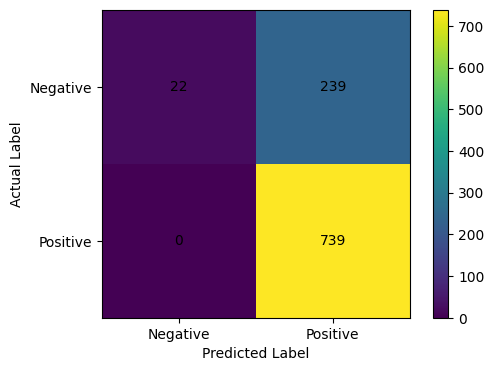

In [56]:
plt.figure(figsize=(6,4))

plt.imshow(cm_nb)

plt.xticks([0,1], ["Negative", "Positive"])
plt.yticks([0,1], ["Negative", "Positive"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_nb[i, j], ha="center", va="center")

plt.colorbar()

plt.show()

# Load Dataset 2024

In [57]:
import glob
import json

In [58]:
jsonl_files = glob.glob("../datasets/2024/*.jsonl")

len(jsonl_files)

219

# Combine Dataset 2024

In [59]:
reviews_2024 = []

In [60]:
for file in jsonl_files:
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            reviews_2024.append(json.loads(line))

In [61]:
df_2024 = pd.DataFrame(reviews_2024)

In [62]:
df_2024.shape

(7448, 18)

# Check Dataset 2024 Structure

In [63]:
df_2024.head()

,source,anime_id,anime_title,season,year,review_id,review_text,review_score,helpful_count,date,user,is_spoiler,is_preliminary,tags,episodes_watched,review_url,type,reactions
0,jikan,39894,Hibike! Euphonium 3,Spring,2024,529399,"Kyoto Animation, almost without fail, has time...",10,146,2024-06-30T01:29:00+00:00,Mcsuper,False,False,[Recommended],None,https://myanimelist.net/reviews.php?id=529399,anime,"{'overall': 146, 'nice': 34, 'love_it': 93, 'f..."
1,jikan,39894,Hibike! Euphonium 3,Spring,2024,529429,Sound! Euphonium is my favorite anime of all t...,6,87,2024-06-30T05:17:00+00:00,DarkVoyagerx,False,False,[Mixed Feelings],None,https://myanimelist.net/reviews.php?id=529429,anime,"{'overall': 87, 'nice': 57, 'love_it': 7, 'fun..."
2,jikan,39894,Hibike! Euphonium 3,Spring,2024,530874,There's a scene in Sound!Euphonium Season 3 wh...,10,20,2024-07-13T16:38:00+00:00,zhewww,False,False,[Recommended],None,https://myanimelist.net/reviews.php?id=530874,anime,"{'overall': 20, 'nice': 2, 'love_it': 15, 'fun..."
3,jikan,39894,Hibike! Euphonium 3,Spring,2024,529413,5 years on from the horrific fire that claimed...,10,17,2024-06-30T03:24:00+00:00,Marinate1016,False,False,[Recommended],None,https://myanimelist.net/reviews.php?id=529413,anime,"{'overall': 17, 'nice': 5, 'love_it': 7, 'funn..."
4,jikan,39894,Hibike! Euphonium 3,Spring,2024,529562,[This review assumes you have watched the prev...,9,15,2024-06-30T18:42:00+00:00,GentleDragonite,False,False,"[Recommended, Well-written]",None,https://myanimelist.net/reviews.php?id=529562,anime,"{'overall': 15, 'nice': 9, 'love_it': 2, 'funn..."


# Create Sample Dataset 2024

In [64]:
df_2024_sample = df_2024.sample(5000, random_state=42)

In [65]:
df_2024_sample.shape

(5000, 18)

# Sentiment Labeling Dataset 2024

In [66]:
df_2024_sample["sentiment"] = df_2024_sample["review_score"].apply(label_sentiment)

# Text Preprocessing Dataset 2024

In [67]:
df_2024_sample["processed_review"] = df_2024_sample["review_text"].apply(clean_text)

In [68]:
df_2024_sample["final_review"] = df_2024_sample["processed_review"].apply(remove_stopwords)

# Dataset 2024 TF-IDF Transformation

In [69]:
X_2024 = tfidf.transform(df_2024_sample["final_review"])

# Dataset 2024 Target Label

In [70]:
y_2024 = df_2024_sample["sentiment"]

# Concept Drift Testing

In [71]:
y_pred_2024_nb = nb_model.predict(X_2024)

# Dataset 2024 Naïve Bayes Evaluation

In [72]:
accuracy_2024_nb = accuracy_score(y_2024, y_pred_2024_nb)

print("Dataset 2024 Naïve Bayes Accuracy:", accuracy_2024_nb)

Dataset 2024 Naïve Bayes Accuracy: 0.617


# Dataset 2024 KNN Testing

In [73]:
y_pred_2024_knn = knn_model.predict(X_2024)

# Dataset 2024 KNN Evaluation

In [74]:
accuracy_2024_knn = accuracy_score(y_2024, y_pred_2024_knn)

print("Dataset 2024 KNN Accuracy:", accuracy_2024_knn)

Dataset 2024 KNN Accuracy: 0.6194


In [75]:
from sklearn.metrics import confusion_matrix

# Dataset 2024 Naïve Bayes Confusion Matrix

In [76]:
cm_2024_nb = confusion_matrix(y_2024, y_pred_2024_nb)

print(cm_2024_nb)

[[ 191 1904]
 [  11 2894]]


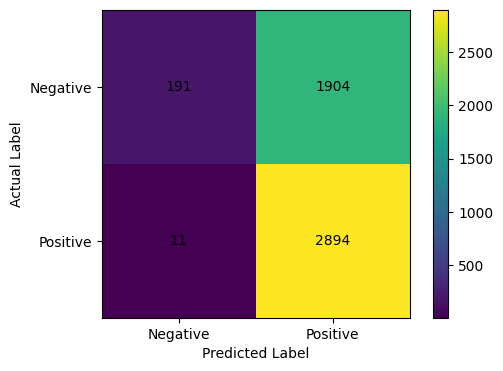

In [77]:
plt.figure(figsize=(6,4))

plt.imshow(cm_2024_nb)

plt.xticks([0,1], ["Negative", "Positive"])
plt.yticks([0,1], ["Negative", "Positive"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_2024_nb[i, j], ha="center", va="center")

plt.colorbar()

plt.show()

# Accuracy Comparison Visualization

In [78]:
models = ["Naïve Bayes", "KNN"]

accuracy_2020 = [76.1, 68.8]
accuracy_2024 = [61.7, 61.94]

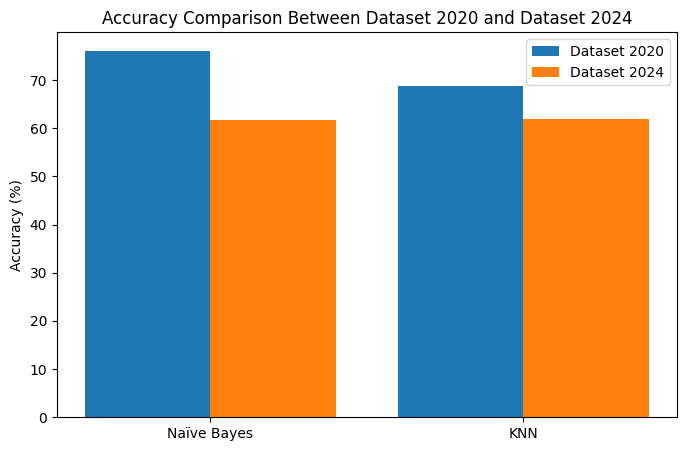

In [79]:
import matplotlib.pyplot as plt

x = range(len(models))

plt.figure(figsize=(8,5))

plt.bar(x, accuracy_2020, width=0.4, label="Dataset 2020")
plt.bar([i + 0.4 for i in x], accuracy_2024, width=0.4, label="Dataset 2024")

plt.xticks([i + 0.2 for i in x], models)

plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison Between Dataset 2020 and Dataset 2024")

plt.legend()

plt.show()

# Performance Decrease Analysis

In [81]:
nb_drop = round(76.1 - 61.7, 2)
knn_drop = round(68.8 - 61.94, 2)

print("Naïve Bayes Performance Decrease:", nb_drop, "%")
print("KNN Performance Decrease:", knn_drop, "%")

Naïve Bayes Performance Decrease: 14.4 %
KNN Performance Decrease: 6.86 %
